# Classification of Toy Model trajectories

### 1. Imports | Import Data | Compute Embedding Markov Model and Clustering

In [1]:
# imports
import numpy as np
from scipy.special import entr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import plotly.express as px
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

import seaborn as sns
import pickle
import importlib

import sys
sys.path.append('../../')

import src.viz

import src.embedding_position
importlib.reload(src.embedding_position)
from src.embedding_position import EmbeddingPosition

import src.markov_analysis
importlib.reload(src.markov_analysis)
from src.markov_analysis import Markov

from src.crisp_pccap import crisp_PCCAp

def average_curvature_angle(traj: np.ndarray, degrees: bool = False) -> float:
    """<
    Compute the average curvature angle along a 3D trajectory.

    Parameters
    ----------
    traj : (T, 3) ndarray
        Sequence of 3D points.
    degrees : bool, optional
        If True, return the average angle in degrees. Otherwise radians.

    Returns
    -------
    float
        Average curvature angle. NaN if fewer than one valid interior angle.

    Notes
    -----
    - Angle at index i is the angle between segments (r[i] - r[i-1]) and (r[i+1] - r[i]).
    - Zero-length steps are skipped.
    """
    traj = np.asarray(traj)
    if traj.ndim != 2 or traj.shape[1] != 3:
        raise ValueError("traj must have shape (T, 3)")
    if traj.shape[0] < 3:
        return np.nan

    # Segment vectors between consecutive points
    seg = np.diff(traj, axis=0)                # shape (T-1, 3)
    seg_norm = np.linalg.norm(seg, axis=1)     # shape (T-1,)

    # Pairs of consecutive segments define interior angles
    v0 = seg[:-1]
    v1 = seg[1:]
    n0 = seg_norm[:-1]
    n1 = seg_norm[1:]

    # Mask out angles involving any zero-length segment
    eps = 1e-12
    mask = (n0 > eps) & (n1 > eps)
    if not np.any(mask):
        return np.nan

    v0 = v0[mask]
    v1 = v1[mask]
    n0 = n0[mask]
    n1 = n1[mask]

    # Cosine of angles with numerical safety
    cos_theta = np.einsum('ij,ij->i', v0, v1) / (n0 * n1)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    angles = np.arccos(cos_theta)  # radians
    avg = angles.mean()
    return np.degrees(avg) if degrees else avg
def label_partition(partitions, profiles, counts):
    result = []
    n_features = profiles.shape[1]
    
    for part in partitions:
        # Calculate total weight for this partition
        total_weight = np.sum(counts[part])
        
        if total_weight > 0:
            # Standard weighted average
            weighted_sum = np.sum(counts[part, np.newaxis] * profiles[part], axis=0)
            result.append(weighted_sum / total_weight)
        else:
            # Handle empty partition or zero weight: return a zero vector
            result.append(np.zeros(n_features))
            
    return np.array(result)

/home/hugo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import raw data
names = ['persistent_straight','stereotypes2','stereotypes4','straight_helix']
dfs = list()
for name in names:
    dfs.append(pd.read_parquet('../../data/toy_model/interim/phases_'+name+'.parquet'))

In [3]:
# compute embedding and clusters 
embs = list()
ks = [5,10,10,10]
ncs = [10,100,100,100]
for df in dfs:
    embs.append(EmbeddingPosition(df,columns=[],columns_translated=['x','y','z'],ID_NAME='label'))
for k,emb in zip(ks,embs):
    emb.make_embedding(K=k)
for nc,emb in zip(ncs,embs):
    emb.make_cluster(n_clusters=nc)
mkvs = list()
for emb in embs:
    mkvs.append(Markov(emb,tau = 10))
for mkv in mkvs:
    mkv.make_transition_matrix()
    mkv.compute_spectrum()
    mkv.reversibilized_matrix()
    mkv.compute_tr_spectrum()
# recompute umap :
data = list()
for emb in embs:
    data.append(emb.fit_umap())

/home/hugo/miniconda3/lib/python3.13/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/hugo/miniconda3/lib/python3.13/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


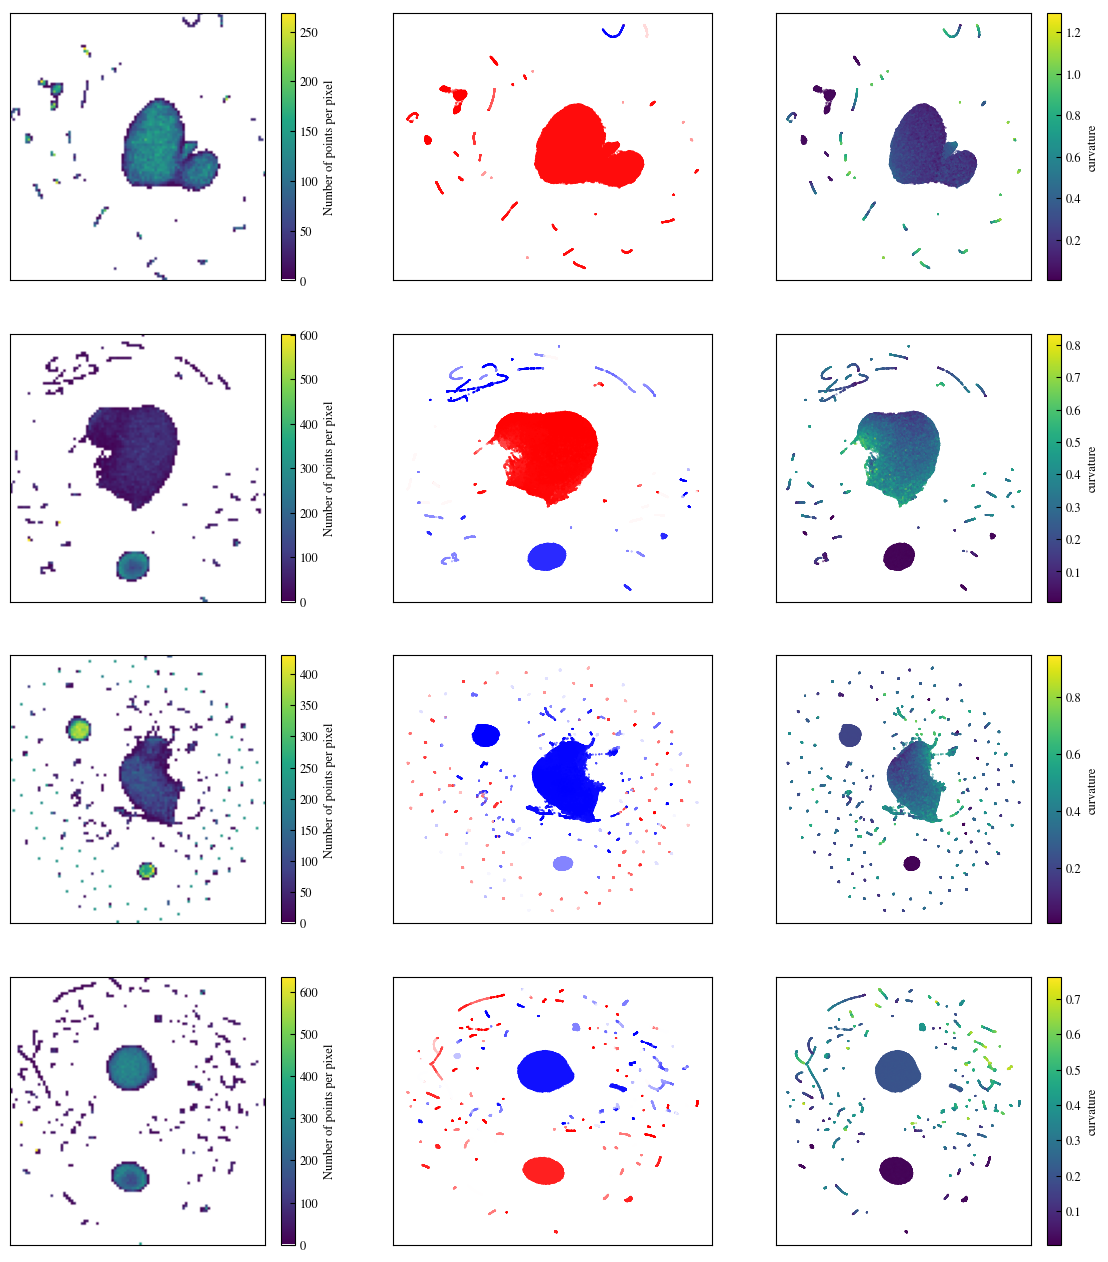

In [4]:
# Plot UMAP
fig,ax = plt.subplots(ncols=3,nrows = embs.__len__(), figsize=(14,4*embs.__len__()),subplot_kw={'projection':'scatter_density'})


for i in range(embs.__len__()):
    curvature = np.array([average_curvature_angle(traj.reshape(-1,3)) for traj in embs[i].flatten_embedding_matrix])



    src.viz.use_mpl_scatter_density(fig,data[i][0][:,0],data[i][0][:,1],ax=ax[i,0],dpi=50)
    ax2 = ax[i,2].scatter(data[i][0][:,0],data[i][0][:,1],c=curvature,s=0.1,rasterized=True)#embs[i].labels,s=0.1)
    ax[i,1].scatter(data[i][0][:, 0],data[i][0][:, 1],c = mkvs[i].tr_slow_modes[:,-1][mkvs[i].labels],s=0.1,cmap='bwr',rasterized=True)
    fig.colorbar(ax2, label='curvature')

    for j in range(3):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

theshold based on max of the min of both curves : 0.01
theshold based on max of the min of both curves : -0.05
theshold based on max of the min of both curves : -0.02
theshold based on max of the min of both curves : 0.03


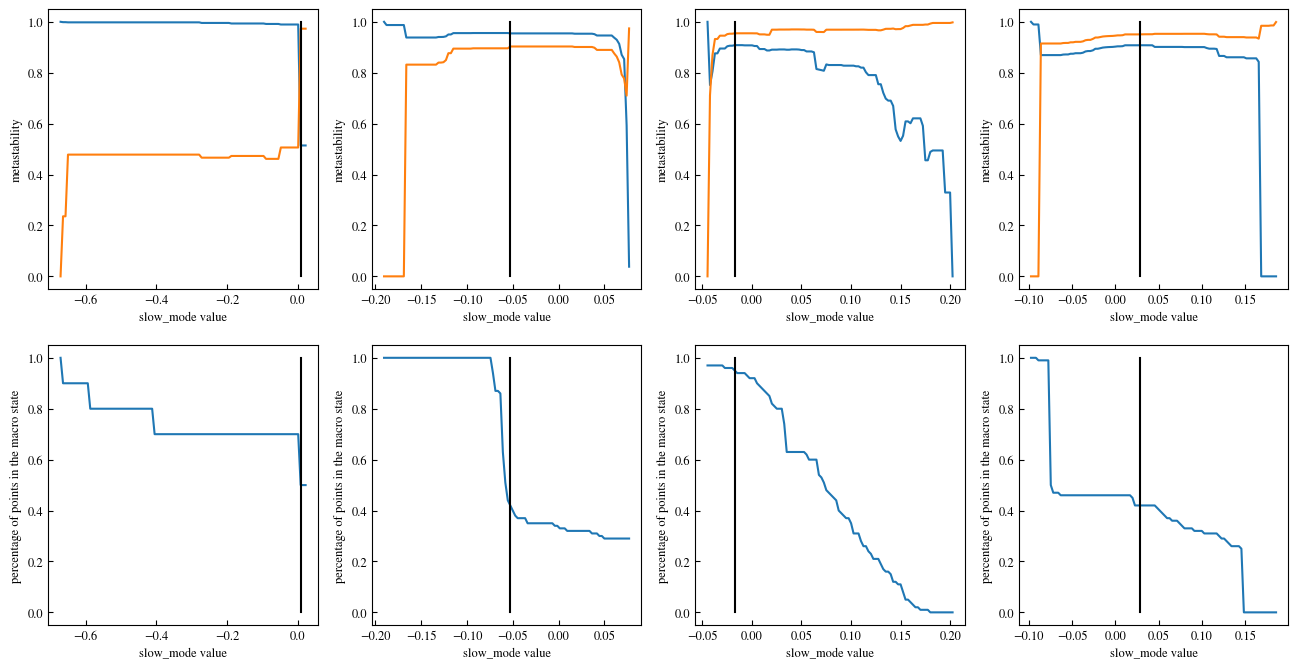

In [5]:
# Plot metastability
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 4, height_ratios=[1,1], width_ratios=[1,1,1,1])
ax = list()
for i in range(4):
    ax.append(fig.add_subplot(gs[0,i]))
    ax.append(fig.add_subplot(gs[1,i]))

thresholds = list()
for i in range(4):
    mkv = mkvs[i]
    mkv.compute_metastability(time_reversed=True)
    threshold1 = mkv.thresholds[np.argmax([min(a,b) for a,b in zip(mkv.meta_in,mkv.meta_out)])]
    thresholds.append(threshold1)
    print(f"theshold based on max of the min of both curves : {threshold1:.2f}")
    #threshold1 = - 0.00
    ax[2*i].plot(mkv.thresholds,mkv.meta_in)
    ax[2*i].plot(mkv.thresholds,mkv.meta_out)
    ax[2*i].set_xlabel('slow_mode value')
    ax[2*i].set_ylabel('metastability')
    cluster_percent = np.array([np.argwhere(mkv.slow_mode>threshold)[:,0].__len__() for threshold in mkv.thresholds])/mkv.slow_mode.__len__()
    ax[2*i+1].plot(mkv.thresholds,cluster_percent)
    
    ax[2*i].plot([threshold1,threshold1],[0,1],color='black')
    ax[2*i+1].plot([threshold1,threshold1],[0,1],color='black')

    ax[2*i+1].set_xlabel('slow_mode value')
    ax[2*i+1].set_ylabel('percentage of points in the macro state')


### 2. Coarse Graining Using the method from Costa et. al.

[1] Costa, Antonio C., Tosif Ahamed, David Jordan, and Greg J. Stephens. “A Markovian Dynamics for Caenorhabditis Elegans Behavior across Scales.” Proceedings of the National Academy of Sciences 121, no. 32 (2024): e2318805121. https://doi.org/10.1073/pnas.2318805121.

In [6]:
Ncs = [2,3,4,5,6,7,8,9,10,12,15]
partitions_labels = list()
entr_labelss = list()
NCs_recursive = list()
for i in range(embs.__len__()): # loop on the different stereotypes
    partition_labels=list()
    entr_labels = list()
    ncs = list()
    for Nc in Ncs: # loop on the # of clusters
        partitions = mkvs[i].recursive_partition(n_states=Nc)
        ncs.append(len(partitions))
        profiles,label_names,counts,global_profile = embs[i].cluster_label_profile()
        partition_labels.append(label_partition(partitions,profiles,counts))
        entr_labels.append(np.sum(entr(partition_labels[-1]),axis=1))
    entr_labelss.append(entr_labels)
    partitions_labels.append(partition_labels)
    NCs_recursive.append(ncs)

Stopping partition: No more splittable partitions. Found 10 states.
Stopping partition: No more splittable partitions. Found 10 states.
No meaningful split found (max min-metastability <= 0). Treating partition as final.
No meaningful split found (max min-metastability <= 0). Treating partition as final.


In [7]:
partitions.__len__()

15

### 3. Coarse Graining using PCCA+

In [8]:
for i in range(mkvs.__len__()):
    print(mkvs[i].P.shape)

(10, 10)
(100, 100)
(100, 100)
(100, 100)


In [9]:
Memberships = list()
Hs = list()
NCs_pcca = list()
PCCAs = list()
for j in range(mkvs.__len__()):
    print('mkv model number :',j)
    membership = list()
    hs = list()
    pccas = list()
    ncs = list()
    for i in Ncs:
        #print('cluster size', i)
        try:
            pcca = crisp_PCCAp(mkvs[j].Pr,n_clusters=np.min([i,mkvs[j].P.shape[0]-1]))
            pccas.append(pcca)
        except:
            pass

        partitions = [np.argwhere(pcca.res.labels==i)[:,0] for i in range(i)]
        profiles,label_names,counts,global_profile = embs[j].cluster_label_profile()
        hs.append(np.sum(entr(label_partition(partitions,profiles,counts)),axis=1))
        ncs.append(len(set(pcca.res.labels)))
        
        #hs.append(pcca.coarse_entropy_rate())
    PCCAs.append(pccas)
    NCs_pcca.append(ncs)
    Hs.append(hs)

mkv model number : 0
mkv model number : 1


/home/hugo/miniconda3/lib/python3.13/site-packages/deeptime/markov/tools/analysis/dense/_pcca.py:259: ComplexWarning: Casting complex values to real discards the imaginary part
  evecs[:, i] /= math.sqrt(np.dot(evecs[:, i] * pi, evecs[:, i]))


mkv model number : 2
mkv model number : 3


/home/hugo/miniconda3/lib/python3.13/site-packages/deeptime/markov/tools/analysis/dense/_pcca.py:265: UserWarning: The given transition matrix has complex eigenvectors, so it doesn't exactly fulfill detailed balance. Forcing eigenvectors to be real and continuing. Be aware that this is not theoretically solid.
  warnings.warn(


[np.float64(0.15002685108435337), np.float64(0.25787800595400684), np.float64(0.2679814232645512), np.float64(0.37101488890611095), np.float64(0.11564381643294157), np.float64(0.23638986125689776), np.float64(0.2431533822370272), np.float64(0.21613633976624647), np.float64(0.1945227057896218), np.float64(0.16210225482468485), np.float64(0.12968180385974787)]
[np.float64(0.08055501694959971), np.float64(0.17752461605442138), np.float64(0.040277508474799856), np.float64(0.061886808290839125), np.float64(0.029466605716066227), np.float64(0.05059818842723075), np.float64(0.020138754237399928), np.float64(0.017901114877688824), np.float64(0.042722276400994574), np.float64(0.07855954343409428), np.float64(0.025161846725883043)]
[np.float64(0.6538726949113962), np.float64(0.4883277629363598), np.float64(0.36443215857999955), np.float64(0.3286214272299469), np.float64(0.24956869447990415), np.float64(0.22708736373568408), np.float64(0.23640548805385642), np.float64(0.24385027881423385), np.flo

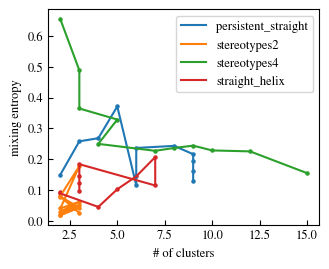

In [12]:
for i,(ncs,hs) in enumerate(zip(NCs_pcca,Hs)):
    print([np.mean(entr) for entr in hs])
    plt.scatter(ncs,[np.mean(entr) for entr in hs],s=5.)
    plt.plot(ncs,[np.mean(entr) for entr in hs],label = names[i])
plt.ylabel('mixing entropy')
plt.xlabel('# of clusters')
plt.legend()

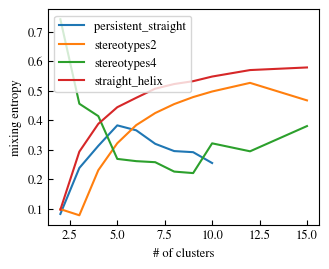

In [13]:
for i,(ncs,entrs) in enumerate(zip(NCs_recursive,entr_labelss)):
    plt.plot(ncs,[np.mean(entr) for entr in entrs],label = names[i])
plt.ylabel('mixing entropy')
plt.xlabel('# of clusters')
plt.legend()

In [25]:
optimal_nc_pcca = np.array([ncs[np.argmin([np.mean(entr) for entr in entr_labels])] for ncs,entr_labels in zip(NCs_pcca,Hs)])
optimal_nc_recursive = np.array([ncs[np.argmin([np.mean(entr) for entr in entr_labels])] for ncs,entr_labels in zip(NCs_recursive,entr_labelss)])

In [26]:
print(optimal_nc_pcca)
print(optimal_nc_recursive)

[ 6  2 15  4]
[2 3 9 2]


In [56]:
flatten_embedding_int_label= list()
for i in range(embs.__len__()):
    profiles,label_names,counts,global_profile = embs[i].cluster_label_profile()
    label_dict = {label_name:i for i,label_name in enumerate(label_names)}
    flatten_embedding_int_label.append([np.mean([label_dict[label] for label in embs[i].flatten_embedding_labels[j]]) for j in range(embs[i].flatten_embedding_labels.shape[0])]) 

ValueError: 'c' argument has 98800 elements, which is inconsistent with 'x' and 'y' with size 99300.

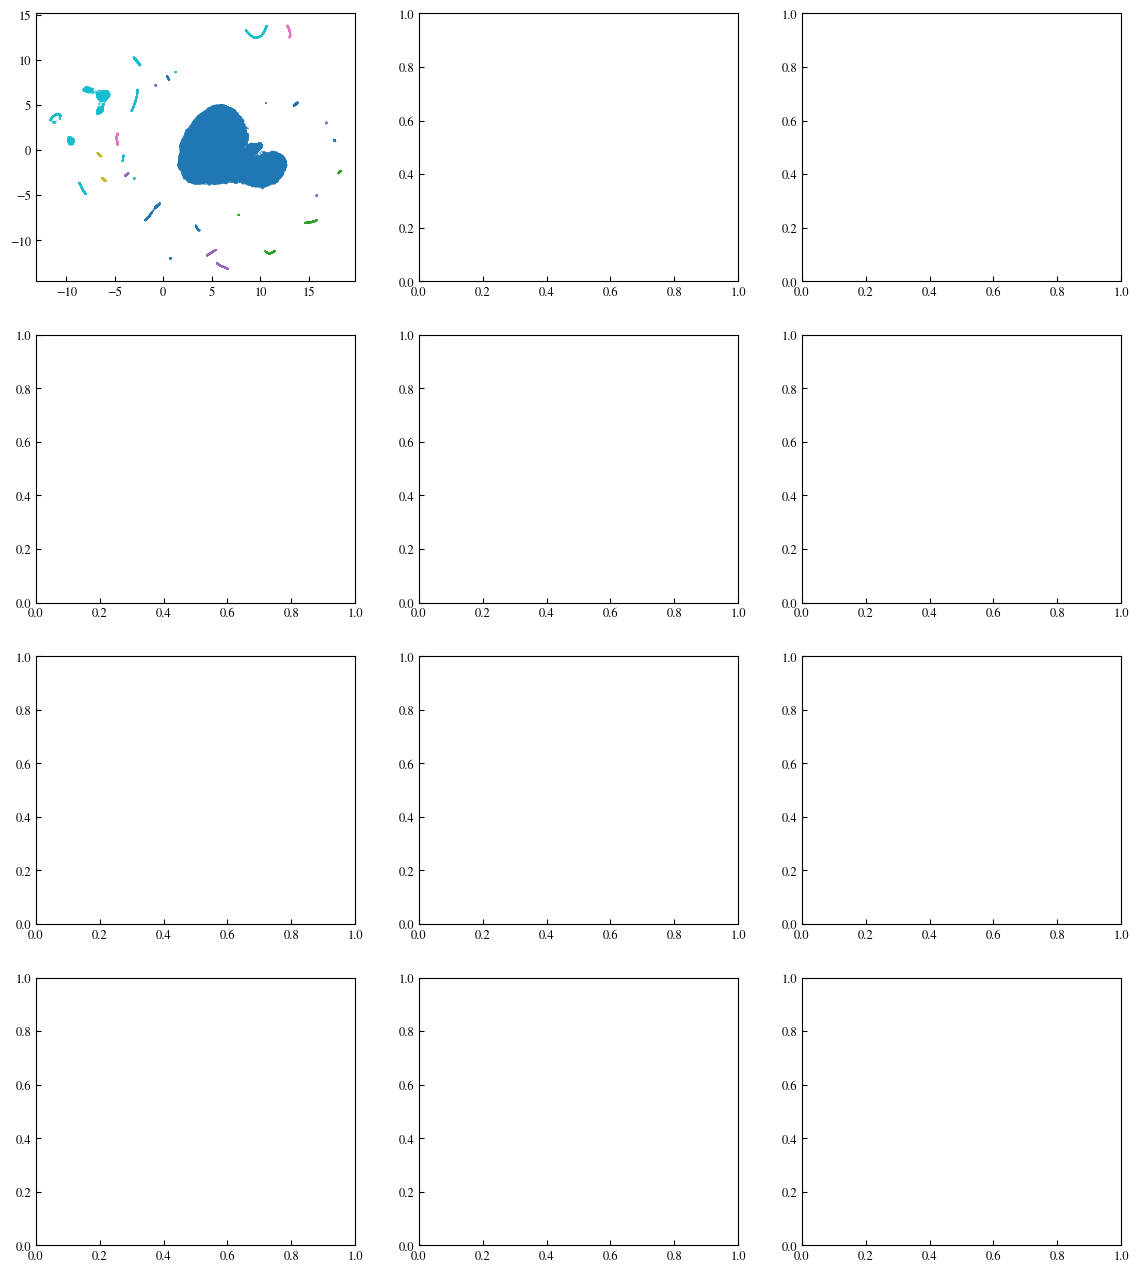

In [ ]:
# Plot UMAP
fig,ax = plt.subplots(ncols=3,nrows = embs.__len__(), figsize=(14,4*embs.__len__()),subplot_kw={'projection':'scatter_density'})


for i in range(embs.__len__()):
    flatten_embedding_int_label = [np.mean([label_dict[label] for label in embs[i].flatten_embedding_labels[j]]) for j in range(embs[i].flatten_embedding_labels.shape[0])]
    ax[i,0].scatter(data[i][0][:,0],data[i][0][:,1],c=flatten_embedding_int_label,s=0.1,rasterized=True,cmap = 'tab10')#embs[i].labels,s=0.1)
    
    ax2 = ax[i,2].scatter(data[i][0][:,0],data[i][0][:,1],c=curvature,s=0.1,rasterized=True)#embs[i].labels,s=0.1)
    ax[i,1].scatter(data[i][0][:, 0],data[i][0][:, 1],c = mkvs[i].tr_slow_modes[:,-1][mkvs[i].labels],s=0.1,cmap='bwr',rasterized=True)
    fig.colorbar(ax2, label='curvature')

    for j in range(3):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])